## Mount Drive & copy images

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/mini_proj_data/images /content/images


Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/mini_proj_data/images': No such file or directory


## Load CSV, prepare metadata, labels, splits

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
import os

df = pd.read_csv('/content/drive/MyDrive/mini_proj_data/processed_data.csv')
df = df[['image_path','clean_path','age','sex','localization','dx','dx_type']].copy()

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].str.lower().replace({'nan': np.nan, 'unknown': np.nan, '': np.nan})
df['sex'] = df['sex'].map({'male':0,'female':1})
df['sex'] = df['sex'].fillna(-1).astype('float32')

df = df.dropna(subset=['clean_path','dx'])
for col in ['localization','dx_type']:
    df[col] = df[col].fillna('unknown')
df = pd.get_dummies(df, columns=['localization','dx_type'], drop_first=False)

scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']]).astype('float32')

feature_cols = ['age_scaled','sex'] + [c for c in df.columns if c.startswith('localization_') or c.startswith('dx_type_')]
X_meta_all = df[feature_cols].values.astype('float32')

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df['dx'])
class_names = label_encoder.classes_
num_classes = len(class_names)
y_all_cat = to_categorical(y_all, num_classes=num_classes).astype('float32')

def map_to_local(path):
    return str(path).replace('/content/drive/MyDrive/mini_proj_data/images', '/content/images')

image_paths_all = df['clean_path'].astype(str).apply(map_to_local).values
missing = [p for p in image_paths_all if not os.path.exists(p)]
if len(missing) > 0:
    keep_mask = np.array([p not in missing for p in image_paths_all])
    image_paths_all = image_paths_all[keep_mask]
    X_meta_all = X_meta_all[keep_mask]
    y_all_cat = y_all_cat[keep_mask]
    y_all = y_all[keep_mask]

train_idx, temp_idx = train_test_split(np.arange(len(y_all)), test_size=0.3, stratify=y_all, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

train_paths, val_paths, test_paths = image_paths_all[train_idx], image_paths_all[val_idx], image_paths_all[test_idx]
train_meta,  val_meta,  test_meta  = X_meta_all[train_idx], X_meta_all[val_idx], X_meta_all[test_idx]
train_labels, val_labels, test_labels = y_all_cat[train_idx], y_all_cat[val_idx], y_all_cat[test_idx]

chosen_loss = 'categorical_crossentropy'
print(f"Dataset sizes: train={len(train_paths)}, val={len(val_paths)}, test={len(test_paths)}, num_classes={num_classes}")


Dataset sizes: train=8236, val=1765, test=1766, num_classes=7


## tf.data pipelines

In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return tf.clip_by_value(image, 0.0, 1.0)

def preprocess_meta(meta):
    meta = tf.cast(meta, tf.float32)
    return tf.clip_by_value(meta, -5.0, 5.0)

ds_train_imgs = tf.data.Dataset.from_tensor_slices(train_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_val_imgs   = tf.data.Dataset.from_tensor_slices(val_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
ds_test_imgs  = tf.data.Dataset.from_tensor_slices(test_paths).map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

ds_train_meta = tf.data.Dataset.from_tensor_slices(train_meta.astype('float32')).map(preprocess_meta)
ds_val_meta   = tf.data.Dataset.from_tensor_slices(val_meta.astype('float32')).map(preprocess_meta)
ds_test_meta  = tf.data.Dataset.from_tensor_slices(test_meta.astype('float32')).map(preprocess_meta)

ds_train_lab = tf.data.Dataset.from_tensor_slices(train_labels.astype('float32'))
ds_val_lab   = tf.data.Dataset.from_tensor_slices(val_labels.astype('float32'))
ds_test_lab  = tf.data.Dataset.from_tensor_slices(test_labels.astype('float32'))

train_ds = tf.data.Dataset.zip(((ds_train_imgs, ds_train_meta), ds_train_lab)).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = tf.data.Dataset.zip(((ds_val_imgs, ds_val_meta), ds_val_lab)).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = tf.data.Dataset.zip(((ds_test_imgs, ds_test_meta), ds_test_lab)).batch(BATCH_SIZE).prefetch(AUTOTUNE)


## Custom CNN architecture (from Table)

In [4]:
from tensorflow.keras import layers, Model

def build_branch_first():
    x_in = layers.Input(shape=(*IMG_SIZE,3))
    x = layers.Conv2D(32,(3,3),activation='relu',padding="same")(x_in)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64,(3,3),activation='relu',padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128,(3,3),activation='relu',padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(256,(3,3),activation='relu',padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return Model(x_in, x, name="FirstCNN")

def build_branch_second():
    x_in = layers.Input(shape=(*IMG_SIZE,3))
    x = layers.Conv2D(256,(7,7),activation='relu',padding="same")(x_in)
    x = layers.AveragePooling2D((2,2))(x)
    x = layers.Conv2D(128,(5,5),activation='relu',padding="same")(x)
    x = layers.AveragePooling2D((2,2))(x)
    x = layers.Conv2D(96,(3,3),activation='relu',padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return Model(x_in, x, name="SecondCNN")

def build_branch_third():
    x_in = layers.Input(shape=(*IMG_SIZE,3))
    x = layers.Conv2D(32,(3,3),activation='relu',padding="same")(x_in)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(96,(5,5),activation='relu',padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128,(5,5),activation='relu',padding="same")(x)
    x = layers.Conv2D(256,(7,7),activation='relu',padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return Model(x_in, x, name="ThirdCNN")

def build_branch_fourth():
    x_in = layers.Input(shape=(*IMG_SIZE,3))
    x = layers.Conv2D(32,(3,3),activation='relu',padding="same")(x_in)
    x = layers.AveragePooling2D((3,3))(x)
    x = layers.Conv2D(32,(3,3),activation='relu',padding="same")(x)
    x = layers.AveragePooling2D((3,3))(x)
    x = layers.Conv2D(64,(5,5),activation='relu',padding="same")(x)
    x = layers.AveragePooling2D((3,3))(x)
    x = layers.Conv2D(128,(5,5),activation='relu',padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return Model(x_in, x, name="FourthCNN")

first = build_branch_first()
second = build_branch_second()
third = build_branch_third()
fourth = build_branch_fourth()

image_input = layers.Input(shape=(*IMG_SIZE,3), name="image_input", dtype=tf.float32)
meta_input  = layers.Input(shape=(train_meta.shape[1],), name="metadata_input", dtype=tf.float32)

f1 = first(image_input)
f2 = second(image_input)
f3 = third(image_input)
f4 = fourth(image_input)

fusion = layers.Concatenate()([f1,f2,f3,f4,meta_input])
x = layers.Dense(256, activation="relu")(fusion)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs=[image_input, meta_input], outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FirstCNN            │ (None, 256)       │    388,416 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SecondCNN           │ (None, 96)        │    967,904 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ThirdCNN            │ (None, 256)       │  1,991,008 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FourthCNN           │ (None, 128)       │    266,336 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 757)       │          0 │ FirstCNN[0][0],   │
│ (Concatenate)       │                   │            │ SecondCNN[0][0],  │
│                     │                   │            │ ThirdCNN[0][0],   │
│                     │                   │            │ FourthCNN[0][0],  │
│                     │                   │            │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    194,048 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │        455 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,849,319 (14.68 MB)

 Trainable params: 3,849,319 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

## Compile, train, evaluate

258/258 ━━━━━━━━━━━━━━━━━━━━ 1480s 5s/step - accuracy: 0.5291 - loss: 1.4838 - val_accuracy: 0.5813 - val_loss: 1.2115
Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 128s 486ms/step - accuracy: 0.5929 - loss: 1.1883 - val_accuracy: 0.6261 - val_loss: 1.0624 - learning_rate: 1.0000e-04
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 517ms/step - accuracy: 0.6428 - loss: 1.0594 - val_accuracy: 0.6754 - val_loss: 0.9189 - learning_rate: 1.0000e-04
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 134s 510ms/step - accuracy: 0.6725 - loss: 0.9336 - val_accuracy: 0.7037 - val_loss: 0.8610 - learning_rate: 1.0000e-04
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 137s 523ms/step - accuracy: 0.6963 - loss: 0.8656 - val_accuracy: 0.7377 - val_loss: 0.7691 - learning_rate: 1.0000e-04
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 134s 510ms/step - accuracy: 0.7144 - loss: 0.8185 - val_accuracy: 0.7286 - val_loss: 0.7410 - learning_rate: 1.0000e-04
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 142s 509ms/step - accuracy: 0.7200 - loss

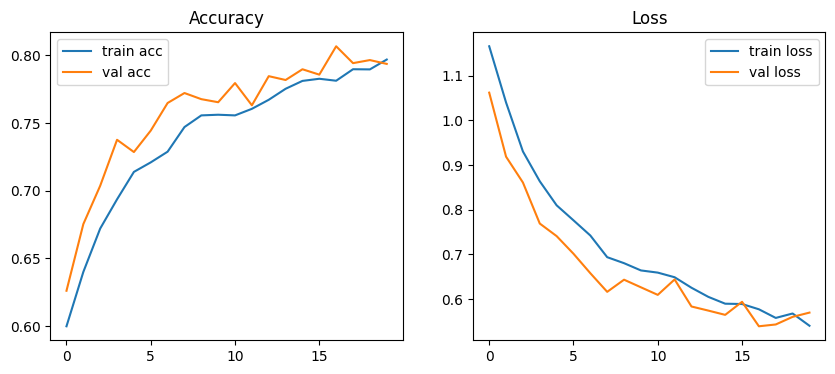

In [5]:
from tensorflow.keras import optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

opt = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=opt, loss=chosen_loss, metrics=["accuracy"])

class TerminateOnNaN(callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        if logs is not None:
            loss = logs.get("loss")
            if loss is not None and (tf.math.is_nan(loss) or tf.math.is_inf(loss)):
                self.model.stop_training = True

# smoke test
smoke = model.fit(train_ds, validation_data=val_ds, epochs=1, callbacks=[TerminateOnNaN()], verbose=1)

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6),
    TerminateOnNaN()
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=cb, verbose=1)

results = model.evaluate(test_ds)
print("Test results:", results)

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# safer y_true extraction
y_true_batches = []
for _, lbls in test_ds:
    y_true_batches.append(np.argmax(lbls.numpy(), axis=1))
y_true = np.concatenate(y_true_batches, axis=0)

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print(confusion_matrix(y_true, y_pred))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train acc')
plt.plot(history.history.get('val_accuracy', []), label='val acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train loss')
plt.plot(history.history.get('val_loss', []), label='val loss')
plt.legend(); plt.title('Loss')
plt.show()

model.save("custom_cnn_metadata_model.h5")
